In [3]:
# ---------------------------------------------
# 1. IMPORTS
# ---------------------------------------------
import requests
import pandas as pd
import numpy as np

# ---------------------------------------------
# 2. FETCH WEATHER DATA FROM OPEN-METEO
# ---------------------------------------------
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 48.78,   # Stuttgart
    "longitude": 9.18,
    "hourly": "temperature_2m,relative_humidity_2m"
}

response = requests.get(url, params=params)
weather_data = response.json()

df_weather = pd.DataFrame({
    "time": weather_data["hourly"]["time"],
    "temperature_outside": weather_data["hourly"]["temperature_2m"],
    "humidity_outside": weather_data["hourly"]["relative_humidity_2m"]
})

df_weather["time"] = pd.to_datetime(df_weather["time"])
df_weather["hour"] = df_weather["time"].dt.hour

# ---------------------------------------------
# 3. SYNTHETIC ELECTRICITY PRICE (REALISTIC DAILY PATTERN)
# ---------------------------------------------
hours = df_weather["hour"].values

# Daily sine wave pattern (peak in evening)
base_price = 0.25 + 0.05 * np.sin(2 * np.pi * (hours - 6) / 24)

# Add noise
noise = np.random.normal(0, 0.01, size=len(df_weather))

df_weather["electricity_price"] = base_price + noise

# ---------------------------------------------
# 4. ROOM TEMPERATURE + COOLING INTENSITY
# ---------------------------------------------
setpoint_temp = 2.5
alpha_outside = 0.05
alpha_price = 0.4

price_norm = df_weather["electricity_price"] - df_weather["electricity_price"].mean()

df_weather["room_temperature"] = (
    setpoint_temp
    + alpha_outside * (df_weather["temperature_outside"] - 5)
    + alpha_price * price_norm
)

price_min = df_weather["electricity_price"].min()
price_max = df_weather["electricity_price"].max()

df_weather["cooling_intensity"] = 1 - (df_weather["electricity_price"] - price_min) / (price_max - price_min)

# ---------------------------------------------
# 5. STORAGE DAYS
# ---------------------------------------------
df_weather["storage_days"] = (df_weather.index / 24).astype(int)

# ---------------------------------------------
# 6. SIMULATE CO2 AND FIRMNESS
# ---------------------------------------------
df_weather["co2"] = (
    0.4
    + 0.002 * df_weather["storage_days"]
    + 0.01 * (df_weather["room_temperature"] - 2.5)
)

df_weather["firmness"] = (
    8
    - 0.03 * df_weather["storage_days"]
    - 0.1 * (df_weather["room_temperature"] - 2.5)
)

# ---------------------------------------------
# 7. SPOILAGE PROBABILITY + LABEL
# ---------------------------------------------
spoilage_prob = (
    0.03 * df_weather["storage_days"]
    + 0.4 * (df_weather["room_temperature"] - 2.5)
    + 0.8 * (df_weather["co2"] - 0.4)
    - 0.5 * df_weather["cooling_intensity"]
    + np.random.normal(0, 0.05, size=len(df_weather))
)

# Convert to binary using percentile threshold (top 30% = spoilage)
threshold = np.percentile(spoilage_prob, 70)
df_weather["spoilage"] = (spoilage_prob > threshold).astype(int)

print(df_weather["spoilage"].value_counts())

spoilage
0    117
1     51
Name: count, dtype: int64


Logistic Regression Accuracy: 0.9705882352941176

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        22
           1       1.00      0.92      0.96        12

    accuracy                           0.97        34
   macro avg       0.98      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34

Random Forest Accuracy: 0.9411764705882353

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       1.00      0.83      0.91        12

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.93        34
weighted avg       0.95      0.94      0.94        34



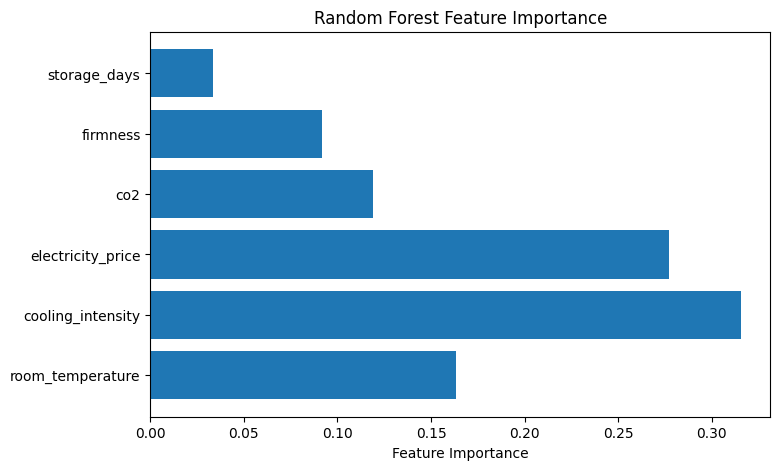

In [4]:
# -------------------------------------------------------
# 9. MACHINE LEARNING MODEL TRAINING
# -------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Select features for ML
features = [
    "room_temperature",
    "cooling_intensity",
    "electricity_price",
    "co2",
    "firmness",
    "storage_days"
]

X = df_weather[features]
y = df_weather["spoilage"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------------------------------
# Logistic Regression
# -------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))

# -------------------------------------------------------
# Random Forest
# -------------------------------------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# -------------------------------------------------------
# Feature Importance Plot (Random Forest)
# -------------------------------------------------------
importances = rf.feature_importances_
plt.figure(figsize=(8, 5))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [5]:
import joblib

joblib.dump(rf, "spoilage_model.pkl")
joblib.dump(scaler, "scaler.pkl")
df_weather.to_csv("dataset.csv", index=False)